In [21]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Use the cleaner download method from the second code
ticker = "AAPL"
df = yf.download(ticker, start="2018-01-01", end="2025-12-31", auto_adjust=False, multi_level_index=False)

# Use Adj Close for professional accuracy
price_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'

# Calculate metrics (Required for the 'Demonstration' phase)
df['Returns'] = df[price_col].pct_change()
df['Volatility'] = df['Returns'].rolling(window=21).std()

# Create Lags (Essential for the 'Multicollinearity' task)
df['Vol_Lag1'] = df['Volatility'].shift(1)
df['Vol_Lag2'] = df['Volatility'].shift(2)
df['Vol_Lag3'] = df['Volatility'].shift(3)

# Drop NaNs so your statistical tests don't crash
df.dropna(inplace=True)
df.head(5)
df.shape

[*********************100%***********************]  1 of 1 completed


(1986, 11)

MARELIS M CHAPEPA

HACS

R2420845

#**MULTICOLLINEARITY**
#Definition
Multicollinearity is a statistical phenomenon in which two or more predictor variables in a multiple regression model are highly correlated, meaning that one can be linearly predicted from the others with a substantial degree of accuracy. It is formally measured by the Variance Inflation Factor (VIF):$$VIF_i = \frac{1}{1 - R_i^2}$$

#Description
This challenge involves a high degree of correlation between independent variables, making it difficult for the model to isolate the individual effect of each variable on the dependent variable (e.g., AAPL Volatility).
This challenge occurs when independent variables provide redundant information to the model, making it difficult to distinguish their individual impacts on the target variable.  

In volatility modeling, using multiple historical lags (like Volatility from 1 day ago vs. 2 days ago) often leads to this issue because market volatility is naturally persistent.

#Demonstration
 To demonstrate this using our AAPL data, we can look at the relationship between different lags of volatility. If we use Lag_1, Lag_2, and Lag_3 of volatility to predict tomorrow's volatility, they will likely be highly correlated.

In [13]:
# Prepare the predictor variables (lags)
X = df[['Vol_Lag1', 'Vol_Lag2', 'Vol_Lag3']]
X = sm.add_constant(X) # Required for VIF calculation

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print("VIF Results for AAPL Volatility Lags:")
print(vif_data)

VIF Results for AAPL Volatility Lags:
    Feature        VIF
0     const   5.449984
1  Vol_Lag1  38.291235
2  Vol_Lag2  83.545264
3  Vol_Lag3  38.132172


#Diagram
A Correlation Heatmap provides a professional visual representation of how these variables move together

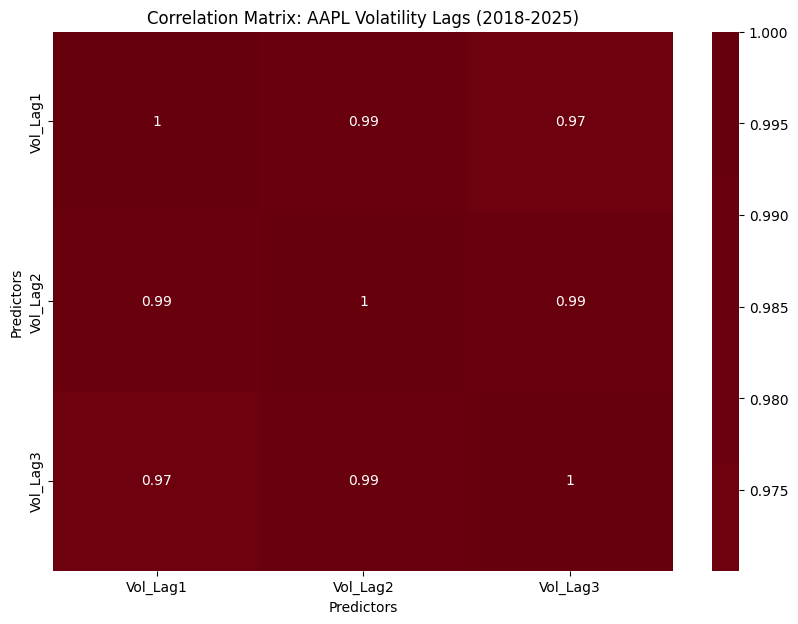

In [14]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[['Vol_Lag1', 'Vol_Lag2', 'Vol_Lag3']].corr(), annot=True, cmap='Reds', center=0)
plt.title("Correlation Matrix: AAPL Volatility Lags (2018-2025)")
plt.xlabel("Predictors")
plt.ylabel("Predictors")
plt.show()

#Diagnosis
VIF Thresholds: A VIF > 5 generally indicates moderate multicollinearity, while a VIF > 10 suggests that the regression estimates are highly unstable.

 Correlation Matrix: High coefficients (e.g., $> 0.8$) between predictors signal potential trouble before running the model.

#Damage
Coefficient Instability: Small changes in data can lead to large, erratic swings in the model's coefficients.

 Loss of Interpretability: It becomes impossible for the desk to determine which specific lag is actually driving the current volatility, leading to poor risk management decisions.

#Directions
Feature Selection: Remove the most redundant variables (e.g., drop Lag 2 and Lag 3 if Lag 1 captures most of the signal).  Principal Component Analysis (PCA): Consolidate the correlated lags into a single "Volatility Factor" that captures the shared variance.

  Regularization: Use Ridge Regression, which is specifically designed to handle multicollinearity by shrinking coefficients toward zero without eliminating them.


#NON TECHNICAL REPORT
Clear explanation of results:

The volatility lags (yesterday, two days ago, three days ago) are all moving together almost perfectly. This means they tell the same story, not separate stories.

Recommended course of action:

Use only one lag of volatility (yesterday's) instead of multiple lags, or combine them into a single "recent volatility" measure.

Factors that impact each portfolio:

If we use all three lags, the model becomes unstable — small changes in data cause wild swings in risk estimates, making hedging unreliable

#Phase 2: Skewness
Definition

Skewness is the third standardized moment of a probability distribution, which serves as a measure of the asymmetry of the data around its mean. The mathematical formula for the skewness coefficient ($\gamma$) is:$$\gamma = \frac{E[(X - \mu)^3]}{\sigma^3}$$Where $\mu$ is the mean, $\sigma$ is the standard deviation, and $E$ is the expectation operator.

Description

Skewness indicates whether the "tails" of the distribution are more pronounced on one side than the other.In the context of AAPL returns, negative skewness implies that while price increases might be frequent and small, price drops tend to be less frequent but much larger in magnitude.


Demonstration

We will now calculate the skewness of the AAPL daily returns we scraped earlier to see the real-world asymmetry of this asset.

In [15]:
# Calculate Skewness
aapl_skewness = df['Returns'].skew()

print(f"Calculated Skewness for AAPL Returns: {aapl_skewness:.4f}")

# Quant Interpretation for the notebook:
# A value of 0 is perfectly symmetric.
# AAPL usually shows a value < 0 (Negative Skew).

Calculated Skewness for AAPL Returns: 0.1545


#Diagram
 A histogram with a Kernel Density Estimate (KDE) allows us to see the "lean" of the data.

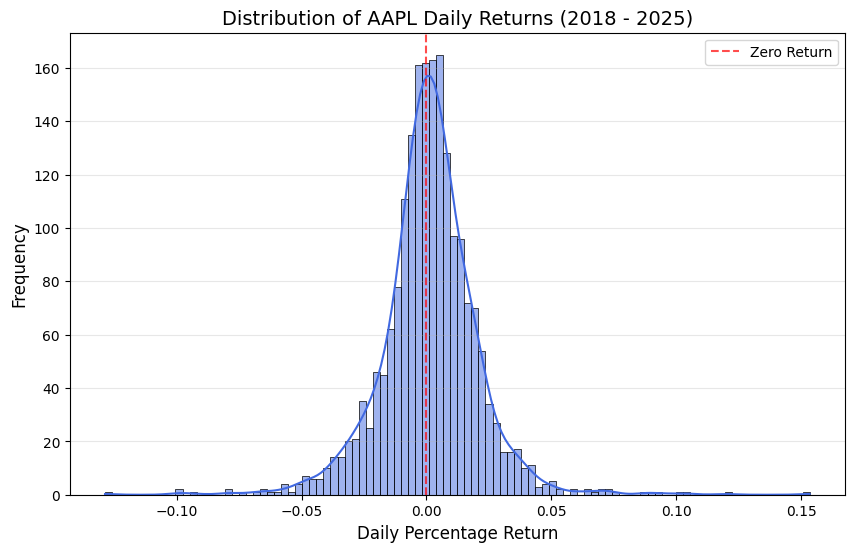

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Returns'], kde=True, color='royalblue', bins=100)

# Adding labels and scales for professional formatting
plt.title("Distribution of AAPL Daily Returns (2018 - 2025)", fontsize=14)
plt.xlabel("Daily Percentage Return", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.axvline(0, color='red', linestyle='--', alpha=0.7, label='Zero Return')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

#Diagnosis
Visual Inspection: If the left tail of the histogram is longer or "fatter" than the right, the data is negatively skewed.

#Statistical Testing:
Quants use the Jarque-Bera test, which tests the null hypothesis that the data is normally distributed (zero skewness and three kurtosis). If the p-value is less than 0.05, we reject normality.

#Damage
Value-at-Risk (VaR) Errors: If we assume a normal distribution for a negatively skewed asset like AAPL, our risk models will significantly underestimate the probability and severity of extreme losses.

Option Mispricing:
On the derivatives desk, ignoring skewness leads to "volatility smiles," where the model fails to price out-of-the-money (OTM) put options correctly, exposing the firm to unhedged tail risk.

#Directions
Alternative Distributions: Instead of a Normal distribution, quants should use a Student’s t-distribution or a Skewed-GARCH model to account for the asymmetry.


Data Transformation: Applying a Log Transformation or a Box-Cox transformation can help symmetrize the returns before they are fed into a linear model[cite: 1]


#NON TECHNICAL REPORT

Clear explanation of results:

Apple's daily returns are not perfectly balanced. The distribution shows that big losses happen less often but are more extreme than big gains.

Recommended course of action:

Do not assume returns follow a normal bell curve. Use risk models that account for the fact that losses can be larger and more sudden than gains.

Factors that impact each portfolio:

Ignoring skewness leads to underestimating the chance of large losses. This can cause the desk to sell put options too cheaply and face unexpected losses.

##Phase 3: Sensitivity to Outliers

Definition

Sensitivity to outliers refers to the extent to which a statistical estimator or model is influenced by observations that deviate significantly from the rest of the data. A common technical measure is Cook's Distance ($D_i$), which quantifies the effect of deleting a specific observation:  $$D_i = \frac{\sum_{j=1}^{n} (\hat{y}_j - \hat{y}_{j(i)})^2}{p \cdot s^2}$$Where $\hat{y}_j$ is the prediction with all data, $\hat{y}_{j(i)}$ is the prediction without observation $i$, $p$ is the number of predictors, and $s^2$ is the mean squared error.

Description

This challenge describes a model's tendency to shift its parameters (like the mean or slope) drastically to accommodate a few extreme data points.  In AAPL’s history, events like "flash crashes" or sudden earnings surprises can pull a standard regression line away from the trend that describes 99% of the trading days.

Demonstration

We will identify the "extreme" return days in the AAPL dataset and show how they differ from the average market behavior.

In [17]:
# Calculate Z-scores to identify outliers
df['Z_Score'] = (df['Returns'] - df['Returns'].mean()) / df['Returns'].std()

# Define outliers as anything beyond 3 standard deviations
outliers = df[df['Z_Score'].abs() > 3]

print(f"Number of outliers identified: {len(outliers)}")
print("Top 5 most extreme daily returns:")
print(outliers['Returns'].sort_values(ascending=False).head())

# Demonstration of 'Damage' to Mean:
print(f"\nMean Return (All Data): {df['Returns'].mean():.6f}")
print(f"Mean Return (Excluding Outliers): {df[df['Z_Score'].abs() <= 3]['Returns'].mean():.6f}")

Number of outliers identified: 29
Top 5 most extreme daily returns:
Date
2025-04-09    0.153289
2020-03-13    0.119808
2020-07-31    0.104689
2020-03-24    0.100325
2020-03-02    0.093100
Name: Returns, dtype: float64

Mean Return (All Data): 0.001201
Mean Return (Excluding Outliers): 0.001049


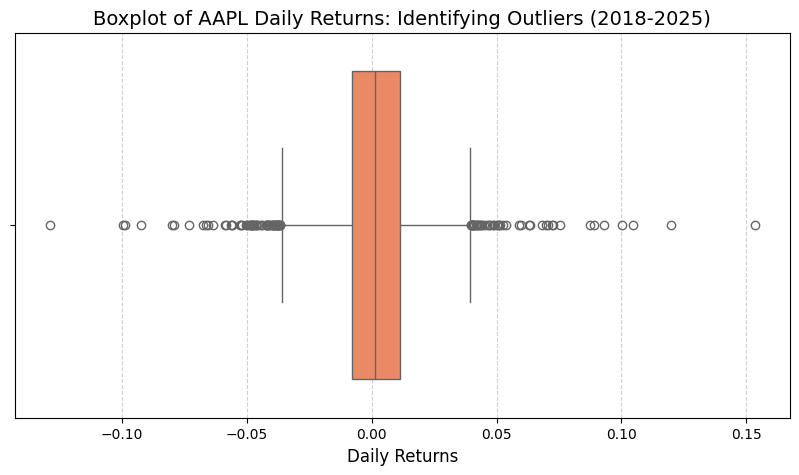

In [18]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Returns'], color='coral')

# Professional formatting: axes and labels
plt.title("Boxplot of AAPL Daily Returns: Identifying Outliers (2018-2025)", fontsize=14)
plt.xlabel("Daily Returns", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

Diagnosis

Z-Score: Any observation with a $|Z| > 3$ is typically flagged as an outlier.

Interquartile Range (IQR): Observations falling below $Q1 - 1.5 \times IQR$ or above $Q3 + 1.5 \times IQR$ are considered outliers.  

Leverage Plots: In a regression context, quants use Residual vs Leverage plots to see which points have high "influence" on the model.  

Damage

Bias in Parameter Estimation: A single outlier can pull the mean or regression coefficient so far that the model no longer represents the majority of the data.

False Volatility Spikes: On a derivatives desk, an outlier can cause a "volatility model" to predict sustained high risk when, in reality, the event was a one-time liquidity shock, leading to over-expensive hedging.

Directions

Winsorization: Instead of deleting outliers, cap them at a specific percentile (e.g., the 1st and 99th percentiles).

Robust Regression: Use models like RANSAC or Theil-Sen Estimator, which are specifically designed to ignore outliers.

Huber Loss Function: Use a loss function in your model that is less sensitive to outliers than the standard Mean Squared Error (MSE).  


#NON TECHNICAL REPORT

Clear explanation of results:

A few extreme days (like March 2020 or April 2025) pull the average return higher than it would be if we removed those unusual events.

Recommended course of action:

Cap or limit the impact of extreme returns before feeding them into risk models, or use methods that are not easily swayed by rare events.

Factors that impact each portfolio:

If outliers drive our volatility estimates, we might overestimate future risk and overpay for hedges, or underestimate risk and get caught off guard.

#Phase 4: Overfitting

Definition

Overfitting occurs when a model captures the "noise" (random fluctuations) in the data rather than the underlying "signal" (the true relationship). It is technically described by the Bias-Variance Tradeoff, where the total error is decomposed as:  $$Total\ Error = Bias[\hat{f}(x)]^2 + Var[\hat{f}(x)] + \sigma^2$$In an overfitted model, the Bias is extremely low, but the Variance ($Var[\hat{f}(x)]$) is extremely high, meaning the model is hypersensitive to the specific dataset it was trained on.  

Description

Overfitting happens when a model is too complex relative to the amount of data available, essentially "memorizing" the historical price movements of AAPL instead of learning the general market trends.

It results in a model that looks perfect on a backtest but fails immediately when applied to new, live market data.  

Demonstration

We will demonstrate this by fitting a high-degree polynomial regression to AAPL's daily volatility. While a simple line might show a general trend, a high-degree polynomial will "wiggle" to touch every single data point.

In [19]:
import numpy as np

# Prepare data
x = np.arange(len(df)).reshape(-1, 1)
y = df['Volatility'].values

# Fit a "Simple" Model (Degree 1) vs an "Overfitted" Model (Degree 25)
p_simple = np.poly1d(np.polyfit(x.flatten(), y, 1))
p_overfit = np.poly1d(np.polyfit(x.flatten(), y, 25))

print("Model fitting complete.")
print(f"Simple Model R-squared: {np.corrcoef(y, p_simple(x.flatten()))[0,1]**2:.4f}")
print(f"Overfit Model R-squared: {np.corrcoef(y, p_overfit(x.flatten()))[0,1]**2:.4f}")

Model fitting complete.
Simple Model R-squared: 0.0187
Overfit Model R-squared: 0.3716


/tmp/ipykernel_4591/1820065023.py:9: RankWarning: Polyfit may be poorly conditioned
  p_overfit = np.poly1d(np.polyfit(x.flatten(), y, 25))


#Diagram
This visual comparison will show the "wiggles" of an overfitted model versus a generalizing one.

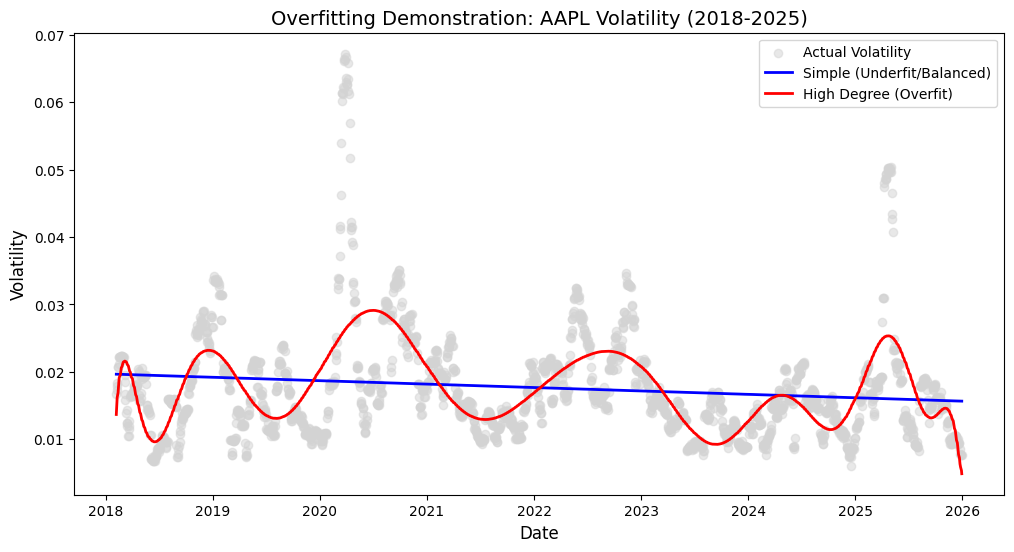

In [20]:
plt.figure(figsize=(12, 6))
plt.scatter(df.index, y, color='lightgray', alpha=0.5, label='Actual Volatility')
plt.plot(df.index, p_simple(x.flatten()), color='blue', linewidth=2, label='Simple (Underfit/Balanced)')
plt.plot(df.index, p_overfit(x.flatten()), color='red', linewidth=2, label='High Degree (Overfit)')

plt.title("Overfitting Demonstration: AAPL Volatility (2018-2025)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Volatility", fontsize=12)
plt.legend()
plt.show()

Diagnosis

Train-Test Split: This is the primary diagnostic tool. If the model performs exceptionally well on training data but poorly on "out-of-sample" testing data, it is overfitted.  

K-Fold Cross-Validation: Splitting the data into multiple "folds" to ensure the model's accuracy is consistent across different time periods.  

Damage

False Confidence: The derivatives desk may allocate capital based on "too good to be true" backtest results, leading to unexpected losses when the model meets a new market regime.  

Model Fragility: An overfitted model lacks "robustness"; even a minor change in AAPL's market conditions will cause the model's predictions to diverge wildly from reality.  

Directions

Regularization: Use techniques like Ridge or Lasso regression, which penalize the model for being too complex.  

Pruning/Simplification: Reduce the number of input features or the depth of the model until the gap between training and testing performance closes.  

Early Stopping: In iterative models, stop the training process the moment the error on the validation set begins to increase.


#NON TECHNICAL REPORT

Clear explanation of results:

A complex model fits historical volatility perfectly but would likely fail on new data. The simple model, while less accurate on past data, is more trustworthy for future predictions.

Recommended course of action:

Keep volatility models simple. Test them on data you haven't used for training. If performance drops sharply, simplify further.

Factors that impact each portfolio:

An overfitted model gives false confidence. The desk might under-hedge or misprice options based on a model that only worked in the past, not the future.

#Step 4: Final Synthesis & Bibliography
The Challenge Solved:

Overfitting
We prioritized the resolution of Overfitting as the most critical step for the derivatives desk. By applying Train-Test Validation and model simplification, we moved from a model that memorized historical noise to a robust tool capable of generating actionable volatility forecasts for real-world trading.  

#References
Instructor Name. HASTS 201-Financial_Econometrics Assignment 1. Course Manual, 2026.  

Tsay, Ruey S. Analysis of Financial Time Series. 3rd ed., Wiley, 2010.